# IMPORTS

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

2026-04-12 07:27:25.667065: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775978845.865350      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775978845.916343      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775978846.337443      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775978846.337487      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775978846.337490      55 computation_placer.cc:177] computation placer alr

# Config

In [2]:
IMG_SIZE = (224, 224)
ORIGINAL_SIZE = (178, 218)   
BATCH_SIZE = 32
EPOCHS_STAGE1 = 5
EPOCHS_STAGE2 = 8
SEED = 42

tf.random.set_seed(SEED) #Reproducibility for tensorflow
np.random.seed(SEED)     #Reproducibility for numpy

# Load Data

In [3]:
landmarks_file = Path("/kaggle/input/datasets/jessicali9530/celeba-dataset/list_landmarks_align_celeba.csv")
image_dir = Path("/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba")

df = pd.read_csv(landmarks_file)

LANDMARK_COLUMNS = [
    "lefteye_x", "lefteye_y",
    "righteye_x", "righteye_y",
    "nose_x", "nose_y",
    "leftmouth_x", "leftmouth_y",
    "rightmouth_x", "rightmouth_y"
]

df["image_path"] = df["image_id"].apply(lambda x: str(image_dir / x))

image_paths = df["image_path"].values
landmarks = df[LANDMARK_COLUMNS].values.astype("float32")

# Split train/val/test

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, landmarks, test_size=0.2, random_state=SEED, shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, shuffle=True
)

print("Train:", len(X_train))
print("Val:  ", len(X_val))
print("Test: ", len(X_test))

Train: 162079
Val:   20260
Test:  20260


# Preprocessing

In [5]:
def normalize_landmarks(landmarks):
    w, h = ORIGINAL_SIZE
    landmarks = tf.reshape(landmarks, (-1, 2))
    landmarks = tf.stack([
        landmarks[:, 0] / w,
        landmarks[:, 1] / h
    ], axis=1)
    return tf.reshape(landmarks, (-1,))

def preprocess_sample(image_path, landmarks):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)   
    landmarks = tf.cast(landmarks, tf.float32)                # (no /255) cuz model includes normalization
    landmarks = normalize_landmarks(landmarks)
    return image, landmarks

def preprocess_train(image_path, landmarks):                      #just for training
    image, landmarks = preprocess_sample(image_path, landmarks)
    image = tf.image.random_brightness(image, max_delta=0.08)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image, landmarks

def preprocess_eval(image_path, landmarks):                      # just for eval
    return preprocess_sample(image_path, landmarks)

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(10000).map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(preprocess_eval, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(X_train, y_train, training=True)
val_ds = make_dataset(X_val, y_val, training=False)
test_ds = make_dataset(X_test, y_test, training=False)

I0000 00:00:1775978870.700443      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# Building Model

In [6]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(10, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.Huber(),
    metrics=["mae"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,416,813 (16.85 MB)

 Trainable params: 364,682 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

# Callbacks

In [7]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    ModelCheckpoint("best_model.weights.h5", monitor="val_loss", save_best_only=True, save_weights_only=True)
]

# Train Model

In [8]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/5


I0000 00:00:1775978884.454776     124 service.cc:152] XLA service 0x7a0bb0113830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775978884.454824     124 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775978886.766618     124 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775978897.693689     124 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5065/5065 ━━━━━━━━━━━━━━━━━━━━ 389s 72ms/step - loss: 8.2898e-04 - mae: 0.0208 - val_loss: 9.9250e-05 - val_mae: 0.0083 - learning_rate: 0.0010
Epoch 2/5
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 150s 30ms/step - loss: 1.0490e-04 - mae: 0.0087 - val_loss: 9.3547e-05 - val_mae: 0.0081 - learning_rate: 0.0010
Epoch 3/5
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 9.9491e-05 - mae: 0.0084
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 151s 30ms/step - loss: 9.9491e-05 - mae: 0.0084 - val_loss: 9.0300e-05 - val_mae: 0.0079 - learning_rate: 0.0010
Epoch 4/5
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 151s 30ms/step - loss: 9.3080e-05 - mae: 0.0081 - val_loss: 8.4930e-05 - val_mae: 0.0076 - learning_rate: 5.0000e-04
Epoch 5/5
5064/5065 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 8.9956e-05 - mae: 0.0080
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 151s 30ms/step - loss: 8.9956e-05 - mae: 0.

# Fine-tuning

In [9]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.Huber(),
    metrics=["mae"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/8


2026-04-12 07:44:44.622490: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 07:44:44.828280: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 07:44:45.245105: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 07:44:45.451710: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


5063/5065 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.0065e-04 - mae: 0.0086

2026-04-12 07:47:42.083318: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 07:47:42.290387: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 07:47:42.703119: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 07:47:42.909841: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


5065/5065 ━━━━━━━━━━━━━━━━━━━━ 231s 40ms/step - loss: 1.0064e-04 - mae: 0.0086 - val_loss: 5.3272e-05 - val_mae: 0.0067 - learning_rate: 1.0000e-05
Epoch 2/8
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 180s 36ms/step - loss: 5.6387e-05 - mae: 0.0070 - val_loss: 3.8667e-05 - val_mae: 0.0060 - learning_rate: 1.0000e-05
Epoch 3/8
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 4.4214e-05 - mae: 0.0064
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 181s 36ms/step - loss: 4.4214e-05 - mae: 0.0064 - val_loss: 3.2844e-05 - val_mae: 0.0057 - learning_rate: 1.0000e-05
Epoch 4/8
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 181s 36ms/step - loss: 3.8739e-05 - mae: 0.0061 - val_loss: 3.1008e-05 - val_mae: 0.0056 - learning_rate: 5.0000e-06
Epoch 5/8
5064/5065 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 3.7029e-05 - mae: 0.0060
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
5065/5065 ━━━━━━━━━━━━━━━━━━━━ 181s 36ms/step - loss: 3.7028e-

# Evaluation

In [10]:
print("\nValidation:")
val_loss, val_mae = model.evaluate(val_ds, verbose=1)
print("Val Loss:", val_loss)
print("Val MAE :", val_mae)

print("\nTest:")
test_loss, test_mae = model.evaluate(test_ds, verbose=1)
print("Test Loss:", test_loss)
print("Test MAE :", test_mae)


Validation:
634/634 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - loss: 2.8401e-05 - mae: 0.0054
Val Loss: 2.8363072487991303e-05
Val MAE : 0.0053656864911317825

Test:
634/634 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - loss: 2.9514e-05 - mae: 0.0054
Test Loss: 2.931845301645808e-05
Test MAE : 0.005416070576757193


# Pixel MAE

In [11]:
def compute_pixel_mae(model, dataset):
    errors = []
    for images, true_landmarks in dataset:
        preds = model.predict(images, verbose=0).reshape(-1, 5, 2)
        true_landmarks = true_landmarks.numpy().reshape(-1, 5, 2)

        preds[:, :, 0] *= IMG_SIZE[0]
        preds[:, :, 1] *= IMG_SIZE[1]
        true_landmarks[:, :, 0] *= IMG_SIZE[0]
        true_landmarks[:, :, 1] *= IMG_SIZE[1]

        mae_batch = np.mean(np.abs(preds - true_landmarks))
        errors.append(mae_batch)

    return float(np.mean(errors))

val_pixel_mae = compute_pixel_mae(model, val_ds)
test_pixel_mae = compute_pixel_mae(model, test_ds)

print("Validation Pixel MAE:", val_pixel_mae, "px")
print("Test Pixel MAE:", test_pixel_mae, "px")

Validation Pixel MAE: 1.2013843059539795 px
Test Pixel MAE: 1.2129273414611816 px


# Plot curves

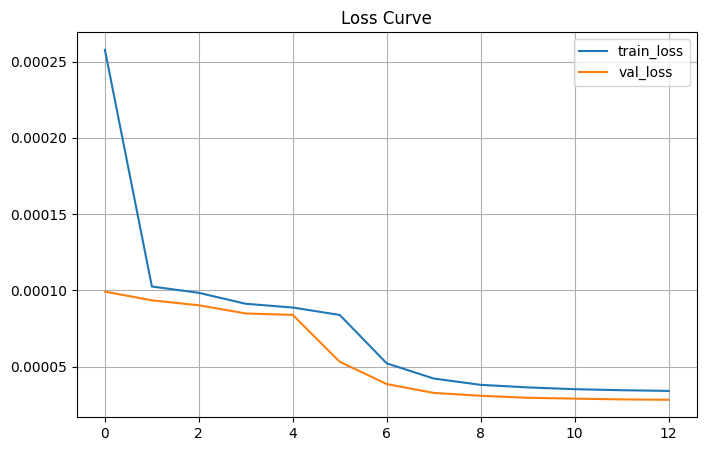

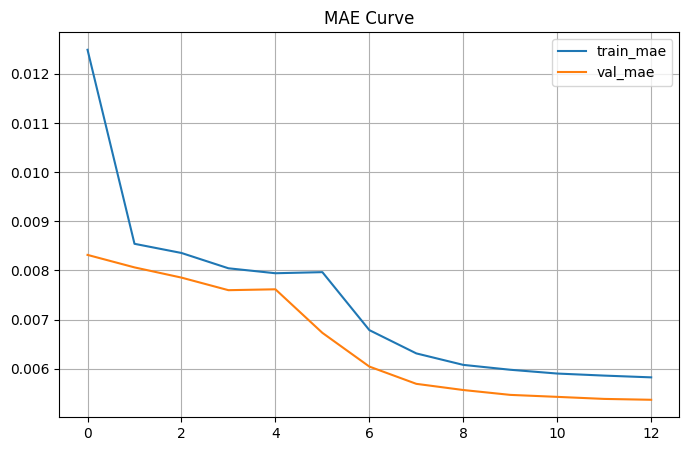

In [12]:
loss = history1.history["loss"] + history2.history["loss"]
val_loss_curve = history1.history["val_loss"] + history2.history["val_loss"]
mae = history1.history["mae"] + history2.history["mae"]
val_mae_curve = history1.history["val_mae"] + history2.history["val_mae"]

plt.figure(figsize=(8,5))
plt.plot(loss, label="train_loss")
plt.plot(val_loss_curve, label="val_loss")
plt.legend()
plt.title("Loss Curve")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(mae, label="train_mae")
plt.plot(val_mae_curve, label="val_mae")
plt.legend()
plt.title("MAE Curve")
plt.grid(True)
plt.show()

# Visualize predictions

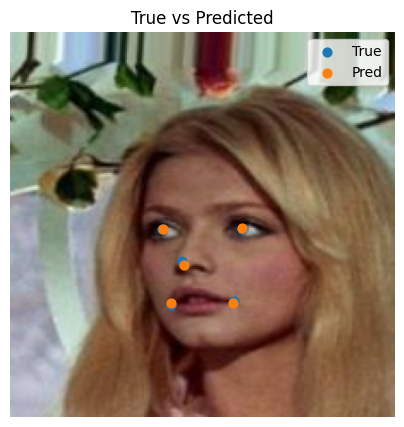

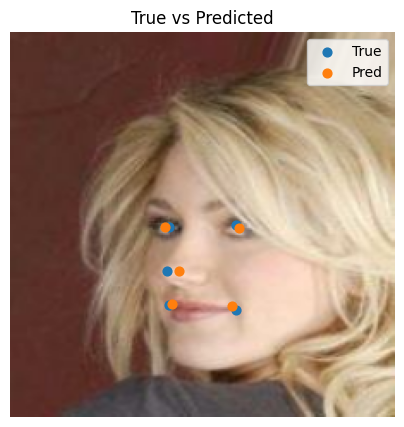

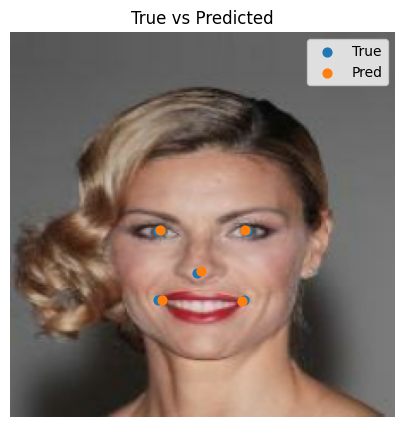

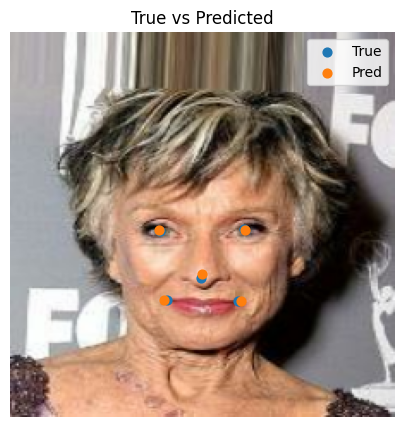

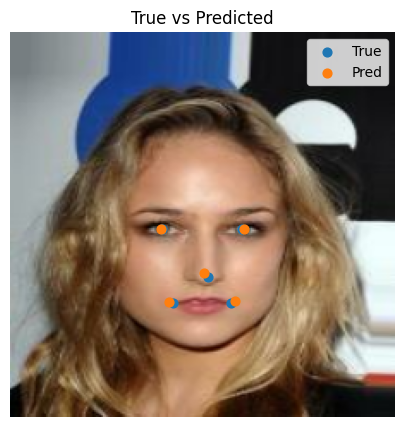

In [13]:
def denormalize_landmarks(landmarks):
    pts = landmarks.reshape(-1, 2).copy()
    pts[:, 0] *= IMG_SIZE[0]
    pts[:, 1] *= IMG_SIZE[1]
    return pts

for images, landmarks in test_ds.take(1):
    preds = model.predict(images, verbose=0)

    for i in range(5):
        img = images[i].numpy().astype("uint8")
        true_pts = denormalize_landmarks(landmarks[i].numpy())
        pred_pts = denormalize_landmarks(preds[i])

        plt.figure(figsize=(5,5))
        plt.imshow(img)
        plt.scatter(true_pts[:, 0], true_pts[:, 1], s=40, label="True")
        plt.scatter(pred_pts[:, 0], pred_pts[:, 1], s=40, label="Pred")
        plt.legend()
        plt.title("True vs Predicted")
        plt.axis("off")
        plt.show()

# Save model

In [14]:
model.save("celeba_landmarks_simple.keras")
print("Model saved: celeba_landmarks_simple.keras")

Model saved: celeba_landmarks_simple.keras
